# Data Caching

This notebook walks through how data is fetched and tokenized for our protein folding models. This notebook will walk through a single file example and then do a set of loops to create a small data cache we can use for our other notebooks. We will search PDB, download a few mmCIF structure files, extract aligned protein chains, tokenize each chain, split accepted chains, and write numeric NumPy shards.

You'll see that for each protein chain, we pull out both the atom and positional information.  Additionally we'll build in masks that help understand what in our tokenized data is real information about the chain and what's padding. Since we're focused on single chain proteins and avoiding multi-chain and non protein molecules, you'll see we throw away some of the info in the mmCIF.

While many folding models rely on MSA, ESMFold2, the inspiration for this series, is able to do single chain folding without MSAs, so you can think of this as that. MSA based inputs would just provide another input to embed and provide into the model.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import py3Dmol
from Bio.PDB import MMCIFParser
from tqdm.auto import tqdm

import data_cache as data_cache
from protein_tokenizer import ESM_PAD_ID, RES_PAD_ID, ProteinTokenizer


In [2]:
data_root = Path('~/data/protein_folding').expanduser()
cache_dir = data_root / 'cache'
search_dir = cache_dir / 'search'
raw_mmcif = data_root / 'mmcif'
manifest_dir = cache_dir / 'manifests'
shard_dir = data_root / 'tokenized'
seed = 1337

for directory in (search_dir, raw_mmcif, manifest_dir, shard_dir):
    directory.mkdir(parents=True, exist_ok=True)


## One-Structure Walkthrough

We'll start with one small mmCIF file before looping over a larger search result. Crambin, `1CRN`, is a compact 46-residue protein, so it is convenient for inspecting the data that we'll extract and understand how a PDB entry becomes a training example. 

In [3]:
example_pdb_id = '1CRN'
example_download = data_cache.download_mmcif(example_pdb_id, raw_mmcif / f'{example_pdb_id}.cif')
example_path = Path(example_download['path'])
print(example_path.name)
print(example_download['status'])
print(f'{example_path.stat().st_size:,} bytes')


1CRN.cif
cached
69,506 bytes


### mmCIF File

The mmCIF file is the **m**acromolecular **c**rystallographic **i**nformation **f**ile. It contains sections separated by `#`, with table and column names such as `_atom_site.Cartn_x`.

The atom table contains one row per observed atom. Biopython turns those rows into a nested hierarchy as follows:
`structure > model > chain > residue > atom`


In [4]:
with example_path.open() as file:
    for _ in range(100):
        print(file.readline().rstrip())


data_1CRN
#
_entry.id   1CRN
#
_audit_conform.dict_name       mmcif_pdbx.dic
_audit_conform.dict_version    5.397
_audit_conform.dict_location   http://mmcif.pdb.org/dictionaries/ascii/mmcif_pdbx.dic
#
loop_
_database_2.database_id
_database_2.database_code
_database_2.pdbx_database_accession
_database_2.pdbx_DOI
PDB   1CRN         pdb_00001crn 10.2210/pdb1crn/pdb
WWPDB D_1000172485 ?            ?
#
loop_
_pdbx_audit_revision_history.ordinal
_pdbx_audit_revision_history.data_content_type
_pdbx_audit_revision_history.major_revision
_pdbx_audit_revision_history.minor_revision
_pdbx_audit_revision_history.revision_date
1 'Structure model' 1 0 1981-07-28
2 'Structure model' 1 1 2008-03-24
3 'Structure model' 1 2 2011-07-13
4 'Structure model' 1 3 2012-07-11
5 'Structure model' 1 4 2017-11-29
6 'Structure model' 1 5 2024-10-30
#
_pdbx_audit_revision_details.ordinal             1
_pdbx_audit_revision_details.revision_ordinal    1
_pdbx_audit_revision_details.data_content_type   'Structure mo

In [5]:
parser = MMCIFParser(auth_chains=True, auth_residues=False, QUIET=True)
structure = parser.get_structure(example_pdb_id, example_path)
model = next(structure.get_models())

for chain in model:
    residues = list(chain)
    print('chain:', chain.id)
    print('residues:', len(residues))
    print('first residue:', residues[0].get_resname())
    print('first residue atoms:', [atom.name for atom in residues[0]])


chain: A
residues: 46
first residue: THR
first residue atoms: ['N', 'CA', 'C', 'O', 'CB', 'OG1', 'CG2']


### Extract Chains

The cache keeps protein chains where sequence position `i`, residue-token row `i`, and atom-coordinate row `i` all describe the same residue. Each accepted residue contributes sequence tokens plus a fixed set of heavy-atom slots. Some slots are observed in the deposited structure and some are not, so the coordinate tensor is paired with an atom mask.

The helper also handles a few important data-cleaning rules:

1. MSE is treated as methionine.
2. unsupported modified residues are rejected.
3. hydrogens are ignored.
4. chains missing a required C-alpha atom are rejected so we can diagnose chain continuity.
5. nonfinite coordinates are rejected.
6. unobserved or zero-occupancy polymer residues are rejected.
7. large adjacent C-alpha jumps are treated as chain breaks.

You'll see C-alpha coordinates used as a local diagnostic for filtering and visualization. The model's representative atom for distogram and confidence is not always C-alpha: for proteins it is CB when present, then CA, then the first valid atom.


In [6]:
EXPLAINER_MAX_CHAIN_LENGTH = 64
MAX_CA_STEP = 5.0


In [7]:
example_records, example_rejections = data_cache.extract_protein_chains(
    example_path,
    min_chain_length=1,
    max_chain_length=EXPLAINER_MAX_CHAIN_LENGTH,
    max_ca_step=MAX_CA_STEP,
)
example = example_records[0]

**Sequence Info**

This is the one-letter amino-acid chain we accepted from the mmCIF file. If its length is below the model context, you'll see how we pad it. If its length is above the context length then we'd cut the length.  

In [8]:
len(example['sequence']), example['sequence']

(46, 'TTCCPSIVARSNFNVCRLPGTPEAICATYTGCIIIPGATCPGDYAN')

**Atom Coordinates**

These are the deposited 3D coordinates for each residue and heavy-atom slot. They are the supervised structure target for folding and diffusion losses wherever the matching atom mask says the atom was resolved.


In [9]:
example['atom_coords'].shape, example['atom_coords']

((46, 37, 3),
 array([[[17.047, 14.099,  3.625],
         [16.967, 12.784,  4.338],
         [15.685, 12.755,  5.133],
         ...,
         [ 0.   ,  0.   ,  0.   ],
         [ 0.   ,  0.   ,  0.   ],
         [ 0.   ,  0.   ,  0.   ]],
 
        [[15.115, 11.555,  5.265],
         [13.856, 11.469,  6.066],
         [14.164, 10.785,  7.379],
         ...,
         [ 0.   ,  0.   ,  0.   ],
         [ 0.   ,  0.   ,  0.   ],
         [ 0.   ,  0.   ,  0.   ]],
 
        [[13.488, 11.241,  8.417],
         [13.66 , 10.707,  9.787],
         [12.269, 10.431, 10.323],
         ...,
         [ 0.   ,  0.   ,  0.   ],
         [ 0.   ,  0.   ,  0.   ],
         [ 0.   ,  0.   ,  0.   ]],
 
        ...,
 
        [[13.725, 11.174, 16.425],
         [13.257, 10.745, 15.081],
         [14.275,  9.687, 14.612],
         ...,
         [ 0.   ,  0.   ,  0.   ],
         [ 0.   ,  0.   ,  0.   ],
         [ 0.   ,  0.   ,  0.   ]],
 
        [[14.342,  8.64 , 15.422],
         [15.445,  7.667, 15

**Atom Mask & Total Atoms**

The atom mask marks which deposited atom slots are actually resolved in the experimental structure. We use it to avoid training on missing coordinates while still keeping a fixed atom-slot layout for every residue.

In [10]:
print('observed atoms:', int(example['atom_mask'].sum()))
example['atom_mask'].shape, example['atom_mask']

observed atoms: 327


((46, 37),
 array([[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False,  True]], shape=(46, 37)))

**Reference Atom Coordinates**

Reference coordinates are local template positions for each atom slot before seeing the deposited structure. The atom encoder uses these as residue-local geometry and identity context, while the model predicts coordinates in the actual structure frame.

In [11]:
example['reference_atom_coords'].shape, example['reference_atom_coords']

((46, 37, 3),
 array([[[-1.25,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 1.52,  0.  ,  0.  ],
         ...,
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]],
 
        [[-1.25,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 1.52,  0.  ,  0.  ],
         ...,
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]],
 
        [[-1.25,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 1.52,  0.  ,  0.  ],
         ...,
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]],
 
        ...,
 
        [[-1.25,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 1.52,  0.  ,  0.  ],
         ...,
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]],
 
        [[-1.25,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 1.52,  0.  ,  0.  ],
         ...,
         [ 0.  ,  0.  ,  

**Reference Atom Mask**

The reference mask marks which atom slots exist for this residue type, independent of whether the deposited experiment resolved them. This is the atom-existence axis used for atom attention and generation, while `atom_mask` is the supervised-coordinate mask.


In [12]:
example['reference_atom_mask'].shape, example['reference_atom_mask']

((46, 37),
 array([[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False]], shape=(46, 37)))

**Atom To Token**

This maps every flattened atom slot back to its residue token row. The folding model uses it to scatter atom features up to residue tokens and gather residue-token updates back down to atoms.


In [13]:
example['atom_to_token'].shape, example['atom_to_token']

((46, 37),
 array([[ 0,  0,  0, ..., -1, -1, -1],
        [ 1,  1,  1, ..., -1, -1, -1],
        [ 2,  2,  2, ..., -1, -1, -1],
        ...,
        [43, 43, 43, ..., -1, -1, -1],
        [44, 44, 44, ..., -1, -1, -1],
        [45, 45, 45, ..., -1, -1, -1]], shape=(46, 37), dtype=int32))

**Atom Element IDs**

These integer IDs encode the chemical element for each atom slot, such as carbon, nitrogen, oxygen, or sulfur. They give the atom encoder basic atom identity information without requiring the model to infer chemistry from the atom name alone.


In [14]:
example['atom_element'].shape, example['atom_element']

((46, 37),
 array([[7, 6, 6, ..., 0, 0, 0],
        [7, 6, 6, ..., 0, 0, 0],
        [7, 6, 6, ..., 0, 0, 0],
        ...,
        [7, 6, 6, ..., 0, 0, 0],
        [7, 6, 6, ..., 0, 0, 0],
        [7, 6, 6, ..., 0, 0, 0]], shape=(46, 37), dtype=int32))

**Atom Charge**

The atom charge field stores the formal-charge channel for each atom slot. Our first protein-only cache is mostly zero here, but the atom encoder still receives the field so the tensor interface matches the atom-level folding path.


In [15]:
example['atom_charge'].shape, example['atom_charge']


((46, 37),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(46, 37), dtype=int32))

**Atom Name Characters**

Atom names are stored as fixed-width character IDs so names like `CA`, `CB`, and `NZ` can be embedded by the model. This differs from Atom Element ID since it captures the atom’s role inside the residue template such as backbone alpha carbon vs carbonyl carbon vs side-chain carbon, first/second branch atoms, terminal oxygens, ring atoms, etc. Element alone is insufficient because many atoms share the same element but mean very different things. For example, backbone CA, carbonyl C, side-chain CB, and aromatic CZ are all carbon. Name characters distinguish their structural role. Atom name alone is also weaker because name strings are residue/template conventions, while element gives explicit chemical type. 

In [16]:
example['atom_name_chars'].shape, example['atom_name_chars']

((46, 37, 4),
 array([[[46,  0,  0,  0],
         [35, 33,  0,  0],
         [35,  0,  0,  0],
         ...,
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  0]],
 
        [[46,  0,  0,  0],
         [35, 33,  0,  0],
         [35,  0,  0,  0],
         ...,
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  0]],
 
        [[46,  0,  0,  0],
         [35, 33,  0,  0],
         [35,  0,  0,  0],
         ...,
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  0]],
 
        ...,
 
        [[46,  0,  0,  0],
         [35, 33,  0,  0],
         [35,  0,  0,  0],
         ...,
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  0]],
 
        [[46,  0,  0,  0],
         [35, 33,  0,  0],
         [35,  0,  0,  0],
         ...,
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  0]],
 
        [[46,  0,  0,  0],
         [35, 33,  0,  0],
         [35,  0,  0, 

**Atom Occupancy**

Occupancy comes from the experimental structure and records how confidently or frequently that atom position was observed. The cache uses it while choosing acceptable atom coordinates and rejecting unsuitable residues.


In [17]:
example['atom_occupancy'].shape, example['atom_occupancy']

((46, 37),
 array([[1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.],
        ...,
        [1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 1.]], shape=(46, 37), dtype=float32))

**Atom Alternative Location**

Alternative-location IDs mark cases where the structure file reports multiple possible positions for an atom. The cache keeps a selected coordinate but preserves this field so we can inspect whether alternate conformations were present.


In [18]:
example['atom_altloc'].shape, example['atom_altloc']

((46, 37),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(46, 37), dtype=int32))

**Residue Atom Bond**

This is the intra-residue heavy-atom bond adjacency for each residue template. It is separate from `token_bonds` since these bonds connect atom slots inside one residue and help build atom-level connectivity features.

In [19]:
example['residue_atom_bonds'].shape, example['residue_atom_bonds']

((46, 37, 37),
 array([[[False,  True, False, ..., False, False, False],
         [ True, False,  True, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],
 
        [[False,  True, False, ..., False, False, False],
         [ True, False,  True, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],
 
        [[False,  True, False, ..., False, False, False],
         [ True, False,  True, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         

**Peptide Bond Mask**

This mask marks the standard protein backbone connection from residue `i` to residue `i + 1`. It is useful for atom-level peptide connectivity. This differs from  `token_bonds` which stays zero for ordinary standard-residue protein chains.

In [20]:
example['peptide_bond_mask'].shape, example['peptide_bond_mask']

((46,),
 array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
        False]))

**Label Sequence ID**

These are the polymer label residue numbers from the mmCIF file. We keep them as residue metadata so cached rows can be traced back to deposited residue numbering and used for relative residue-position features.


In [21]:
example['label_seq_ids'], example['label_seq_ids'].shape

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46], dtype=int32),
 (46,))

## Tokenization

For our tokenization, we'll use the tokenizer we cached in `protein_tokenizer.py`. This tokenizer should mirror the ESM based tokenizer and supports encoding and decoding.  You'll see that we keep two copies of the tokenized protein sequence with slightly different tokenizations since one primarily used for the PLM and a second that goes to the folding backbone. You'll see in different notebook explainers how we use them. 

In [22]:
tokenizer = ProteinTokenizer()
input_ids, res_type = tokenizer.encode(example['sequence'])

print('sequence:', example['sequence'])
print('input IDs:', len(input_ids), input_ids)
print('residue types:', len(res_type), res_type)
print('decoded:', tokenizer.decode(input_ids))

sequence: TTCCPSIVARSNFNVCRLPGTPEAICATYTGCIIIPGATCPGDYAN
input IDs: 46 [11, 11, 23, 23, 14, 8, 12, 7, 5, 10, 8, 17, 18, 17, 7, 23, 10, 4, 14, 6, 11, 14, 9, 5, 12, 23, 5, 11, 19, 11, 6, 23, 12, 12, 12, 14, 6, 5, 11, 23, 14, 6, 13, 19, 5, 17]
residue types: 46 [18, 18, 6, 6, 16, 17, 11, 21, 2, 3, 17, 4, 15, 4, 21, 6, 3, 12, 16, 9, 18, 16, 8, 2, 11, 6, 2, 18, 20, 18, 9, 6, 11, 11, 11, 16, 9, 2, 18, 6, 16, 9, 5, 20, 2, 4]
decoded: TTCCPSIVARSNFNVCRLPGTPEAICATYTGCIIIPGATCPGDYAN


## Build a Small Teaching Cache


### Search and Download

For this explainer, we'll scan 1,000 RCSB entries and keep chains between 16 and 64 residues so every cached example fits directly in the model context. The full training run would use the same helpers with more entries and wider chains. We're using a smaller tensor to keep the outputs semi-readable.

In [23]:
MAX_RESOLUTION = 3.0
NUM_PDB_ENTRIES = 1000
MIN_CHAIN_LENGTH = 16
SHARD_SIZE = 128
TARGET_CHAINS = 1000

### Query PDB

We'll search RCSB for experimental protein entries solved by X-ray diffraction with reported resolution of 3.0 Angstroms or better. The length filters are also included in the query so the downloaded files are likely to contain chains useful for this short explainer cache.

In [24]:
query = data_cache.build_rcsb_query(
    min_chain_length=MIN_CHAIN_LENGTH,
    max_chain_length=EXPLAINER_MAX_CHAIN_LENGTH,
    max_resolution=MAX_RESOLUTION,
    rows=NUM_PDB_ENTRIES,
)

In [25]:
search_result = data_cache.run_or_load_rcsb_search(
    query,
    search_dir / 'rcsb_query.json',
    search_dir / 'rcsb_response.json',
)
pdb_ids = data_cache.extract_pdb_ids(search_result)
data_cache.write_pdb_id_list(search_dir / 'selected_pdb_ids.txt', pdb_ids)

print('matching entries:', search_result['total_count'])
print('selected entries:', len(pdb_ids))
print(pdb_ids[:20])


matching entries: 24067
selected entries: 1000
['10MH', '148L', '1A02', '1A07', '1A08', '1A09', '1A0A', '1A0M', '1A1A', '1A1B', '1A1C', '1A1E', '1A1F', '1A1G', '1A1H', '1A1I', '1A1J', '1A1K', '1A1L', '1A1M']


In [26]:
downloaded_files = []

for pdb_id in tqdm(pdb_ids):
    result = data_cache.download_mmcif(pdb_id, raw_mmcif / f'{pdb_id}.cif')
    downloaded_files.append(result)
    if result['status'] == 'failed':
        error = result['error']
        raise RuntimeError(f'failed to download {pdb_id}: {error}')

print('cached raw files:', len(downloaded_files))

  0%|          | 0/1000 [00:00<?, ?it/s]

cached raw files: 1000


### Extract Chain Records

Now we parse the cached mmCIF files, extract aligned sequence, token, atom-coordinate, atom-feature, and bond arrays. We'll also dedup if there are duplicate chains across files based on sequence. Exact-sequence deduplication is simple, but it avoids training and evaluating on identical chain strings.

In [27]:
records = []
rejections = []
parse_log = []

for pdb_id in tqdm(pdb_ids):
    cif_path = raw_mmcif / f'{pdb_id}.cif'
    accepted, rejected = data_cache.extract_protein_chains(
        cif_path,
        min_chain_length=MIN_CHAIN_LENGTH,
        max_chain_length=EXPLAINER_MAX_CHAIN_LENGTH,
        max_ca_step=MAX_CA_STEP,
    )
    records.extend(accepted)
    rejections.extend(rejected)
    parse_log.append(
        {
            'pdb_id': pdb_id,
            'accepted_chains': len(accepted),
            'rejected_chains': len(rejected),
        }
    )

records, duplicate_rejections = data_cache.deduplicate_records(records)
rejections.extend(duplicate_rejections)
records = records[:TARGET_CHAINS]

(manifest_dir / 'parse_log.jsonl').write_text(
    ''.join(json.dumps(row, sort_keys=True) + '\n' for row in parse_log),
    encoding='utf-8',
)
(manifest_dir / 'rejection_log.jsonl').write_text(
    ''.join(json.dumps(row, sort_keys=True) + '\n' for row in rejections),
    encoding='utf-8',
)

print('accepted chains:', len(records))
print('target accepted chains:', TARGET_CHAINS)
print('rejections:', data_cache.rejection_counts(rejections))


  0%|          | 0/1000 [00:00<?, ?it/s]

accepted chains: 141
target accepted chains: 1000
rejections: {'not_protein': 496, 'too_long': 721, 'missing_required_atom': 1160, 'unsupported_modified_residue': 453, 'too_short': 165, 'chain_break': 2, 'duplicate_sequence': 202}


### Split and Save

The accepted chain records are shuffled with a fixed seed and split into train, validation, and test sets. Each split is written as compressed `.npz` shards and jsonl manifest to link identifiers and sequences. 

In [28]:
splits = data_cache.split_records(records, seed=seed)
for split, split_records_list in splits.items():
    print(split, len(split_records_list))


train 113
val 14
test 14


In [29]:
shard_summaries = []

for split, split_records_list in splits.items():
    if split_records_list:
        summaries = data_cache.write_shards(
            split_records_list,
            split,
            shard_dir,
            max_chain_length=EXPLAINER_MAX_CHAIN_LENGTH,
            examples_per_shard=SHARD_SIZE,
            overwrite=True,
        )
        shard_summaries.extend(summaries)

for summary in shard_summaries:
    print(summary)


{'split': 'train', 'shard': 'protein_folding_train_000000.npz', 'manifest': 'protein_folding_train_000000.jsonl', 'examples': 113, 'valid_residues': 5436, 'array_shape': [113, 64], 'atom_slots': ['N', 'CA', 'C', 'O', 'CB', 'CG', 'CG1', 'CG2', 'OG', 'OG1', 'SG', 'CD', 'CD1', 'CD2', 'ND1', 'ND2', 'OD1', 'OD2', 'SD', 'CE', 'CE1', 'CE2', 'CE3', 'NE', 'NE1', 'NE2', 'OE1', 'OE2', 'CH2', 'NH1', 'NH2', 'OH', 'CZ', 'CZ2', 'CZ3', 'NZ', 'OXT']}
{'split': 'val', 'shard': 'protein_folding_val_000000.npz', 'manifest': 'protein_folding_val_000000.jsonl', 'examples': 14, 'valid_residues': 728, 'array_shape': [14, 64], 'atom_slots': ['N', 'CA', 'C', 'O', 'CB', 'CG', 'CG1', 'CG2', 'OG', 'OG1', 'SG', 'CD', 'CD1', 'CD2', 'ND1', 'ND2', 'OD1', 'OD2', 'SD', 'CE', 'CE1', 'CE2', 'CE3', 'NE', 'NE1', 'NE2', 'OE1', 'OE2', 'CH2', 'NH1', 'NH2', 'OH', 'CZ', 'CZ2', 'CZ3', 'NZ', 'OXT']}
{'split': 'test', 'shard': 'protein_folding_test_000000.npz', 'manifest': 'protein_folding_test_000000.jsonl', 'examples': 14, 'valid

### Reload and Validate a Shard

Let's take a look at a shard, recover a specific chain and map it.

In [30]:
validation_summaries = []

for summary in shard_summaries:
    split_dir = shard_dir / summary['split']
    result = data_cache.validate_shard(
        split_dir / summary['shard'],
        split_dir / summary['manifest'],
        max_ca_step=MAX_CA_STEP,
    )
    validation_summaries.append(result)

In [31]:
dataset_metadata = data_cache.build_dataset_metadata(
    query,
    pdb_ids,
    splits,
    rejections,
    shard_summaries,
    seed,
    MIN_CHAIN_LENGTH,
    EXPLAINER_MAX_CHAIN_LENGTH,
    MAX_RESOLUTION,
    MAX_CA_STEP,
)
statistics = data_cache.dataset_statistics(splits)
dataset_metadata['statistics'] = {
    'split_counts': statistics['split_counts'],
    'amino_acid_counts': statistics['amino_acid_counts'],
    'atom_observation_counts': statistics['atom_observation_counts'],
}

metadata_path = manifest_dir / 'dataset_metadata.json'
metadata_path.write_text(
    json.dumps(dataset_metadata, indent=2, sort_keys=True) + '\n',
    encoding='utf-8',
)

print(metadata_path.name)
print(json.dumps(dataset_metadata['split_counts'], indent=2))
print('metadata atom slots:', len(dataset_metadata['atom_slots']))


dataset_metadata.json
{
  "train": 113,
  "val": 14,
  "test": 14
}
metadata atom slots: 37


In [32]:
first_summary = shard_summaries[0]
first_split_dir = shard_dir / first_summary['split']
first_shard = first_split_dir / first_summary['shard']
first_manifest = first_split_dir / first_summary['manifest']

with np.load(first_shard) as shard:
    stored_input_ids = shard['input_ids'][0]
    stored_res_type = shard['res_type'][0]
    stored_residue_mask = shard['residue_mask'][0]
    stored_atom_coords = shard['atom_coords'][0]
    stored_atom_mask = shard['atom_mask'][0]
    stored_reference_atom_coords = shard['reference_atom_coords'][0]
    stored_reference_atom_mask = shard['reference_atom_mask'][0]
    stored_atom_to_token = shard['atom_to_token'][0]
    stored_atom_element = shard['atom_element'][0]
    stored_atom_charge = shard['atom_charge'][0]
    stored_atom_name_chars = shard['atom_name_chars'][0]
    stored_atom_occupancy = shard['atom_occupancy'][0]
    stored_atom_altloc = shard['atom_altloc'][0]
    derived_atom_slot_ids = np.arange(len(data_cache.HEAVY_ATOM_SLOTS), dtype=np.int32)
    stored_residue_atom_bonds = shard['residue_atom_bonds'][0]
    stored_peptide_bond_mask = shard['peptide_bond_mask'][0]
    stored_token_bonds = shard['token_bonds'][0]
    stored_ref_space_uid = shard['ref_space_uid'][0]
    stored_residue_index = shard['residue_index'][0]
    stored_token_index = shard['token_index'][0]
    stored_asym_id = shard['asym_id'][0]
    stored_sym_id = shard['sym_id'][0]
    stored_entity_id = shard['entity_id'][0]
    stored_mol_type = shard['mol_type'][0]
    stored_label_seq_ids = shard['label_seq_ids'][0]
    stored_lengths = shard['lengths']

with first_manifest.open() as file:
    manifest_row = json.loads(file.readline())

decoded_sequence = tokenizer.decode(stored_input_ids[stored_residue_mask].tolist())

print(manifest_row)
print('decoded sequence:', decoded_sequence)
print('length:', int(stored_lengths[0]))
print('input_ids:', stored_input_ids.shape)
print('res_type:', stored_res_type.shape)
print('residue_mask:', stored_residue_mask.shape)
print('atom_coords:', stored_atom_coords.shape)
print('atom_mask:', stored_atom_mask.shape)
print('reference_atom_coords:', stored_reference_atom_coords.shape)
print('reference_atom_mask:', stored_reference_atom_mask.shape)
print('atom_to_token:', stored_atom_to_token.shape)
print('atom_element:', stored_atom_element.shape)
print('atom_charge:', stored_atom_charge.shape)
print('atom_name_chars:', stored_atom_name_chars.shape)
print('atom_occupancy:', stored_atom_occupancy.shape)
print('atom_altloc:', stored_atom_altloc.shape)
print('derived atom slot IDs:', derived_atom_slot_ids.shape, derived_atom_slot_ids)
print('residue_atom_bonds:', stored_residue_atom_bonds.shape)
print('peptide_bond_mask:', stored_peptide_bond_mask.shape)
print('token_bonds:', stored_token_bonds.shape)
print('ref_space_uid:', stored_ref_space_uid.shape)
print('residue_index:', stored_residue_index.shape)
print('token_index:', stored_token_index.shape)
print('asym_id:', stored_asym_id.shape)
print('sym_id:', stored_sym_id.shape)
print('entity_id:', stored_entity_id.shape)
print('mol_type:', stored_mol_type.shape)
print('label_seq_ids:', stored_label_seq_ids.shape)
print('observed atoms in row:', int(stored_atom_mask.sum()))


{'chain_id': 'J', 'length': 27, 'pdb_id': '1HLT', 'row': 0, 'sequence': 'ADCGLRPLFEKKSLEDKTERELLESYI', 'skipped_atom_names': []}
decoded sequence: ADCGLRPLFEKKSLEDKTERELLESYI
length: 27
input_ids: (64,)
res_type: (64,)
residue_mask: (64,)
atom_coords: (64, 37, 3)
atom_mask: (64, 37)
reference_atom_coords: (64, 37, 3)
reference_atom_mask: (64, 37)
atom_to_token: (64, 37)
atom_element: (64, 37)
atom_charge: (64, 37)
atom_name_chars: (64, 37, 4)
atom_occupancy: (64, 37)
atom_altloc: (64, 37)
derived atom slot IDs: (37,) [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36]
residue_atom_bonds: (64, 37, 37)
peptide_bond_mask: (64,)
token_bonds: (64, 64)
ref_space_uid: (64, 37)
residue_index: (64,)
token_index: (64,)
asym_id: (64,)
sym_id: (64,)
entity_id: (64,)
mol_type: (64,)
label_seq_ids: (64,)
observed atoms in row: 218


### Cached Model Metadata

The folding model uses a few pieces of metadata that are easy to mix up. `residue_atom_bonds` is the intra-residue heavy-atom adjacency. `peptide_bond_mask` tracks ordinary protein backbone connectivity between neighboring residues. `token_bonds` is different: it is the Biohub-style explicit token-level covalent-constraint channel, and for ordinary standard-residue protein chains it should stay zero. We also keep residue, token, chain, symmetry, entity, molecule-type, and reference-space IDs even though this first cache is single-chain and those values are mostly degenerate.

Atom slot IDs are derived from the fixed `data_cache.HEAVY_ATOM_SLOTS` order rather than stored as a separate shard array. The shard stores the per-residue atom tensors; the slot list gives those columns their names.


In [33]:
valid_token_bonds = stored_token_bonds[stored_residue_mask][:, stored_residue_mask]
valid_peptide_bond_mask = stored_peptide_bond_mask[stored_residue_mask]
valid_ref_space_uid = stored_ref_space_uid[stored_residue_mask]

print('standard-protein token bonds:', int(valid_token_bonds.sum()))
print('peptide bond mask:', int(valid_peptide_bond_mask.sum()))
print('unique asym_id:', np.unique(stored_asym_id[stored_residue_mask]))
print('unique sym_id:', np.unique(stored_sym_id[stored_residue_mask]))
print('unique entity_id:', np.unique(stored_entity_id[stored_residue_mask]))
print('unique mol_type:', np.unique(stored_mol_type[stored_residue_mask]))
print('reference-space IDs for first residue:', valid_ref_space_uid[0])


standard-protein token bonds: 0
peptide bond mask: 26
unique asym_id: [0]
unique sym_id: [0]
unique entity_id: [0]
unique mol_type: [0]
reference-space IDs for first residue: [1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


`reference_atom_mask` tells the model which atoms exist for the residue template and therefore belong on the generated atom axis. `atom_mask` tells us which of those atoms were actually resolved in the deposited structure and can supervise coordinate losses. They often match for clean residues, but they are not the same concept.


### Visualize the Cached Structure

We now have enough information to show the actual deposited heavy-atom structure for the cached protein chain. It is a protein-only view with hydrogens, ligands, waters, and other chains removed. The final view uses `py3Dmol` from the cached atom tensor so we can inspect a real protein-style structure without relying on a Jupyter widget extension.


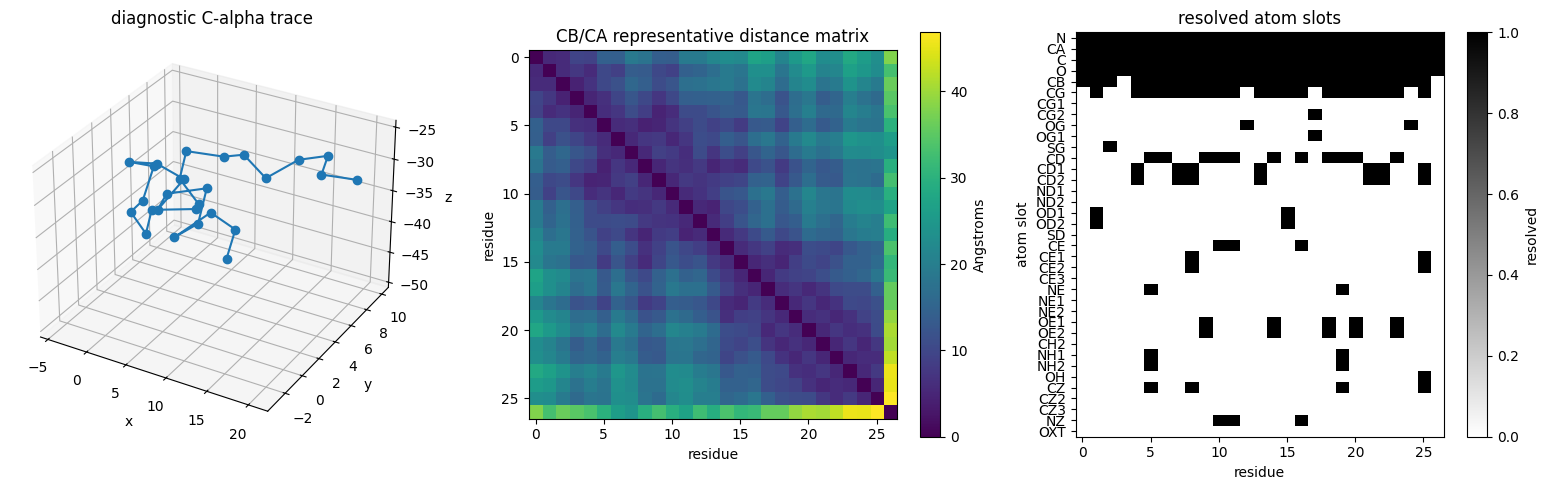

In [34]:
valid_atom_coords = stored_atom_coords[stored_residue_mask]
valid_atom_mask = stored_atom_mask[stored_residue_mask]
valid_reference_atom_mask = stored_reference_atom_mask[stored_residue_mask]
valid_residue_atom_bonds = stored_residue_atom_bonds[stored_residue_mask]
valid_length = int(stored_residue_mask.sum())

ca_index = data_cache.ATOM_SLOT_TO_INDEX['CA']
cb_index = data_cache.ATOM_SLOT_TO_INDEX['CB']
ca_coordinates = valid_atom_coords[:, ca_index, :]
ca_differences = ca_coordinates[:, None, :] - ca_coordinates[None, :, :]
ca_distance_matrix = np.sqrt((ca_differences ** 2).sum(axis=-1))

first_valid_atom = valid_reference_atom_mask.astype(np.int64).argmax(axis=-1)
representative_atom_index = np.where(
    valid_reference_atom_mask[:, cb_index],
    cb_index,
    np.where(valid_reference_atom_mask[:, ca_index], ca_index, first_valid_atom),
)
representative_coords = valid_atom_coords[np.arange(valid_length), representative_atom_index]
representative_differences = representative_coords[:, None, :] - representative_coords[None, :, :]
representative_distance_matrix = np.sqrt((representative_differences ** 2).sum(axis=-1))

figure = plt.figure(figsize=(16, 5))
trace_axes = figure.add_subplot(1, 3, 1, projection='3d')
trace_axes.plot(ca_coordinates[:, 0], ca_coordinates[:, 1], ca_coordinates[:, 2], marker='o')
trace_axes.set_title('diagnostic C-alpha trace')
trace_axes.set_xlabel('x')
trace_axes.set_ylabel('y')
trace_axes.set_zlabel('z')

distance_axes = figure.add_subplot(1, 3, 2)
distance_image = distance_axes.imshow(representative_distance_matrix, cmap='viridis')
distance_axes.set_title('CB/CA representative distance matrix')
distance_axes.set_xlabel('residue')
distance_axes.set_ylabel('residue')
figure.colorbar(distance_image, ax=distance_axes, label='Angstroms')

mask_axes = figure.add_subplot(1, 3, 3)
mask_image = mask_axes.imshow(valid_atom_mask.T, cmap='gray_r', aspect='auto')
mask_axes.set_title('resolved atom slots')
mask_axes.set_xlabel('residue')
mask_axes.set_ylabel('atom slot')
mask_axes.set_yticks(range(len(data_cache.HEAVY_ATOM_SLOTS)))
mask_axes.set_yticklabels(data_cache.HEAVY_ATOM_SLOTS)
figure.colorbar(mask_image, ax=mask_axes, label='resolved')
plt.tight_layout()


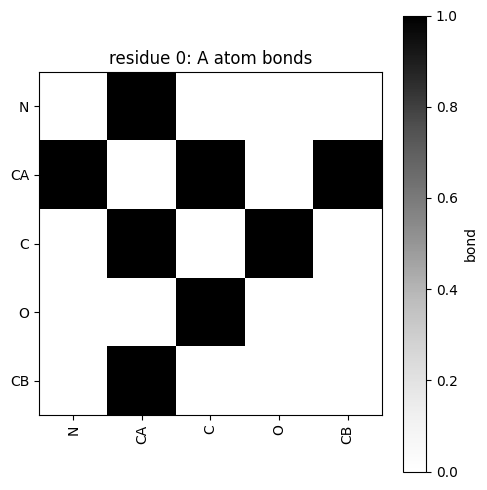

In [35]:
bond_residue_index = 0
bond_slot_indices = np.where(valid_reference_atom_mask[bond_residue_index])[0]
bond_matrix = valid_residue_atom_bonds[bond_residue_index][np.ix_(bond_slot_indices, bond_slot_indices)]
bond_labels = [data_cache.HEAVY_ATOM_SLOTS[index] for index in bond_slot_indices]

figure, axes = plt.subplots(figsize=(5, 5))
image = axes.imshow(bond_matrix, cmap='Greys', vmin=0, vmax=1)
axes.set_title(f'residue {bond_residue_index}: {decoded_sequence[bond_residue_index]} atom bonds')
axes.set_xticks(range(len(bond_labels)))
axes.set_yticks(range(len(bond_labels)))
axes.set_xticklabels(bond_labels, rotation=90)
axes.set_yticklabels(bond_labels)
figure.colorbar(image, ax=axes, label='bond')
plt.tight_layout()


In [36]:
ONE_TO_THREE = {
    'A': 'ALA',
    'R': 'ARG',
    'N': 'ASN',
    'D': 'ASP',
    'C': 'CYS',
    'Q': 'GLN',
    'E': 'GLU',
    'G': 'GLY',
    'H': 'HIS',
    'I': 'ILE',
    'L': 'LEU',
    'K': 'LYS',
    'M': 'MET',
    'F': 'PHE',
    'P': 'PRO',
    'S': 'SER',
    'T': 'THR',
    'W': 'TRP',
    'Y': 'TYR',
    'V': 'VAL',
    'X': 'UNK',
}

valid_label_seq_ids = stored_label_seq_ids[stored_residue_mask]
pdb_lines = []
serial = 1
for residue_index, residue_letter in enumerate(decoded_sequence):
    residue_name = ONE_TO_THREE.get(residue_letter, 'UNK')
    residue_number = int(valid_label_seq_ids[residue_index])
    for atom_index, atom_name in enumerate(data_cache.HEAVY_ATOM_SLOTS):
        if not valid_atom_mask[residue_index, atom_index]:
            continue
        x, y, z = valid_atom_coords[residue_index, atom_index]
        element = atom_name[0] if atom_name[0] in {'C', 'N', 'O', 'S'} else ''
        pdb_lines.append(
            f'ATOM  {serial:5d} {atom_name:>4s} {residue_name:>3s} A{residue_number:4d}    '
            f'{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00          {element:>2s}'
        )
        serial += 1
pdb_lines.append('TER')
pdb_lines.append('END')
cached_pdb_text = '\n'.join(pdb_lines)

view = py3Dmol.view(width=900, height=560)
view.addModel(cached_pdb_text, 'pdb')
#view.setStyle({}, {'cartoon': {'color': 'spectrum'}})
#view.addStyle({}, {'stick': {'radius': 0.14, 'colorscheme': 'Jmol'}})
#view.addStyle({}, {'sphere': {'scale': 0.22, 'colorscheme': 'Jmol', 'opacity': 0.45}})
view.setStyle({}, {'sphere': {'scale': 0.75,'colorscheme': 'Jmol'}})
view.zoomTo()
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Conclusion
Now we have a walk through of what parts of a mmCIF file from PDB is extracted and cached for protein folding. We also show how to run it in a loop, searching PDB and extracting the different components, then padding them to fit our expected context. We now have enough data ready to focus on our model training including the protein language model and folding backbones. 